In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt; plt.style.use("dark_background")
import seaborn as sns
import statsmodels.formula.api as smf
import sys
import sys; sys.path.append("/data/jerrylee/pjt/BIGFAM.v.0.1")

from BIGFAM import tools

# Step 1. filtering

## Step 1.1 GS:SFHS

In [163]:
df_gs = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/X/XmXfR.GS.tsv",
    sep='\t'
)


In [164]:
df_gs_filtered = df_gs[
    (df_gs["lambda"] < 1)
    & (df_gs["lower_Vx_male"] > 1e-6)
    & (df_gs["lower_Vx_female"] > 1e-6)
    ][[
        "pheno", "weight", "lambda", 
        "Vx_male", "lower_Vx_male", "upper_Vx_male",
        "Vx_female", "lower_Vx_female", "upper_Vx_female",
        "r", "lower_r", "upper_r"
    ]]

df_gs_filtered["DCR"] = df_gs_filtered["Vx_male"] / df_gs_filtered["Vx_female"]

In [166]:
# df_gs_filtered.to_csv(
#     "/data/jerrylee/pjt/BIGFAM.v.0.1/data/X/XmXfR.GS.filitered.tsv",
#     sep='\t',
#     index=False
# )

In [2]:
df_gs_filtered = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/X/XmXfR.GS.filitered.tsv",
    sep='\t',
)

## Step 1.2 UKB

In [167]:
df_ukb = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/X/XmXfR.UKB.tsv",
    sep='\t'
)


In [168]:
# remove scores
df_ukb = df_ukb[~df_ukb["pheno"].isin([
    'Living_environment_score__England_', 
    'Education_score__England_',
    'Health_score__England_', 
    'Employment_score__England_', 
    'Crime_score__England_',
    'Housing_score__England_', 
    'Index_of_Multiple_Deprivation__England_',
    'Income_score__England_',
])]

In [169]:
df_ukb_filtered = df_ukb[
    (df_ukb["lambda"] < 1)
    & (df_ukb["lower_Vx_male"] > 1e-6)
    & (df_ukb["lower_Vx_female"] > 1e-6)
    ][[
        "pheno", "weight", "lambda", 
        "Vx_male", "lower_Vx_male", "upper_Vx_male",
        "Vx_female", "lower_Vx_female", "upper_Vx_female",
        "r", "lower_r", "upper_r"
    ]]

df_ukb_filtered["DCR"] = df_ukb_filtered["Vx_male"] / df_ukb_filtered["Vx_female"]
# df_ukb_filtered

In [171]:
df_ukb_check = df_ukb_filtered.copy()
df_ukb_check["Vx/Vg:male"] = df_ukb_check["Vx_male"] / df_ukb_check["lambda"]
df_ukb_check["Vx/Vg:female"] = df_ukb_check["Vx_female"] / df_ukb_check["lambda"]
df_ukb_check.groupby("weight").mean()[[
    "DCR", 
    "Vx_male", "Vx_female",
    "Vx/Vg:male", "Vx/Vg:female",
    "r"
    ]].round(3)

,DCR,Vx_male,Vx_female,Vx/Vg:male,Vx/Vg:female,r
weight,,,,,,
-1,1.702,0.034,0.027,0.103,0.085,0.282
0,2.796,0.023,0.014,0.058,0.034,0.290
1,1.658,0.014,0.009,0.027,0.017,0.200
2,1.909,0.009,0.005,0.015,0.008,0.000
3,1.713,0.005,0.003,0.008,0.005,-0.067
4,1.921,0.003,0.002,0.005,0.003,0.000
5,2.034,0.002,0.001,0.004,0.002,-0.125


In [172]:
# df_ukb_filtered.to_csv(
#     "/data/jerrylee/pjt/BIGFAM.v.0.1/data/X/XmXfR.UKB.filitered.tsv",
#     sep='\t',
#     index=False
# )

In [3]:
df_ukb_filtered = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/X/XmXfR.UKB.filitered.tsv",
    sep='\t',
)

## Step 1.3 GCTA

In [173]:
# convert se to CI
df_gcta = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/GCTA/X.all.gcta",
    sep='\t'
)

In [174]:
gcta_male = df_gcta[df_gcta["sex"] == "male"].copy()
gcta_male["Vx_male"] = gcta_male["X_GCTA"]
gcta_male["lower_Vx_male"] = gcta_male["X_GCTA"] - 1.96 * gcta_male["se_X_GCTA"]
gcta_male["upper_Vx_male"] = gcta_male["X_GCTA"] + 1.96 * gcta_male["se_X_GCTA"]
gcta_male = (gcta_male
               .drop(columns=["n_meta", "sex", "X_GCTA", "se_X_GCTA"]))

gcta_female = df_gcta[df_gcta["sex"] == "female"].copy()
gcta_female["Vx_female"] = gcta_female["X_GCTA"]
gcta_female["lower_Vx_female"] = gcta_female["X_GCTA"] - 1.96 * gcta_female["se_X_GCTA"]
gcta_female["upper_Vx_female"] = gcta_female["X_GCTA"] + 1.96 * gcta_female["se_X_GCTA"]
gcta_female = (gcta_female
               .drop(columns=["n_meta", "sex", "X_GCTA", "se_X_GCTA"]))

df_gcta = pd.merge(
    gcta_male,
    gcta_female,
    on="pheno"
)
df_gcta

,pheno,Vx_male,lower_Vx_male,upper_Vx_male,Vx_female,lower_Vx_female,upper_Vx_female
0,Nucleated_red_blood_cell_percentage,0.004651,-0.000055,0.009356,0.004284,0.000373,0.008195
1,"Hair_colour__natural,_before_greying_",0.004158,-0.000178,0.008495,0.008090,0.004137,0.012042
2,Urate,0.006318,0.001669,0.010968,0.003556,-0.000296,0.007409
3,Standing_height,0.021796,0.016847,0.026745,0.015764,0.011634,0.019895
4,IGF-1,0.010657,0.005788,0.015527,0.004999,0.000991,0.009008
...,...,...,...,...,...,...,...
125,Past_tobacco_smoking,0.005832,0.001073,0.010591,0.004295,0.000165,0.008424
126,Arm_fat-free_mass__right_,0.014670,0.009790,0.019549,0.007924,0.003957,0.011891
127,Forced_vital_capacity__FVC_,0.015693,0.010408,0.020978,0.005404,0.001213,0.009596
128,Neuroticism_score,0.005406,-0.000110,0.010921,0.006252,0.001428,0.011077


In [175]:
# remove scores
df_gcta = df_gcta[~df_gcta["pheno"].isin([
    'Living_environment_score__England_', 
    'Education_score__England_',
    'Health_score__England_', 
    'Employment_score__England_', 
    'Crime_score__England_',
    'Housing_score__England_', 
    'Index_of_Multiple_Deprivation__England_',
    'Income_score__England_',
])]

In [176]:
df_gcta_filtered = df_gcta[
    (df_gcta["lower_Vx_male"] > 1e-6)
    & (df_gcta["lower_Vx_female"] > 1e-6)
    ][[
        "pheno", 
        "Vx_male", "lower_Vx_male", "upper_Vx_male",
        "Vx_female", "lower_Vx_female", "upper_Vx_female",
    ]]

df_gcta_filtered["DCR"] = df_gcta_filtered["Vx_male"] / df_gcta_filtered["Vx_female"]

df_gcta_filtered

,pheno,Vx_male,lower_Vx_male,upper_Vx_male,Vx_female,lower_Vx_female,upper_Vx_female,DCR
3,Standing_height,0.021796,0.016847,0.026745,0.015764,0.011634,0.019895,1.382589
4,IGF-1,0.010657,0.005788,0.015527,0.004999,0.000991,0.009008,2.131783
5,Monocyte_count,0.005917,0.001202,0.010632,0.004222,0.000280,0.008165,1.401266
8,Mean_sphered_cell_volume,0.007942,0.003162,0.012722,0.004587,0.000652,0.008521,1.731415
9,Leg_predicted_mass__left_,0.013430,0.008641,0.018219,0.006692,0.002717,0.010668,2.006754
...,...,...,...,...,...,...,...,...
124,Creatinine,0.006439,0.001694,0.011184,0.004289,0.000308,0.008269,1.501461
125,Past_tobacco_smoking,0.005832,0.001073,0.010591,0.004295,0.000165,0.008424,1.357921
126,Arm_fat-free_mass__right_,0.014670,0.009790,0.019549,0.007924,0.003957,0.011891,1.851305
127,Forced_vital_capacity__FVC_,0.015693,0.010408,0.020978,0.005404,0.001213,0.009596,2.903851


In [177]:
# df_gcta_filtered.to_csv(
#     "/data/jerrylee/pjt/BIGFAM.v.0.1/data/GCTA/XmXf.filtered.gcta",
#     sep='\t',
#     index=False
# )

In [4]:
df_gcta_filtered = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/GCTA/XmXf.filtered.gcta",
    sep='\t',
)

# Step 2. save results for plotting

## Step 2.1 BIGFAM

In [5]:
tmp_gs = df_gs_filtered.copy()
tmp_gs["cohort"] = "GS:SFHS"

tmp_ukb = df_ukb_filtered.copy()
tmp_ukb["cohort"] = "UKB"

df_mrg = pd.concat([tmp_ukb, tmp_gs], axis=0)

In [7]:
for_plot = df_mrg[df_mrg["weight"] == 1]

In [9]:
for_plot.groupby("cohort").size()

cohort
GS:SFHS    12
UKB        20
dtype: int64

In [15]:
for_plot[["Vx_male", "Vx_female", "DCR"]].agg(["mean", "std"])

,Vx_male,Vx_female,DCR
mean,0.011837,0.008053,1.534015
std,0.004826,0.003344,0.496923


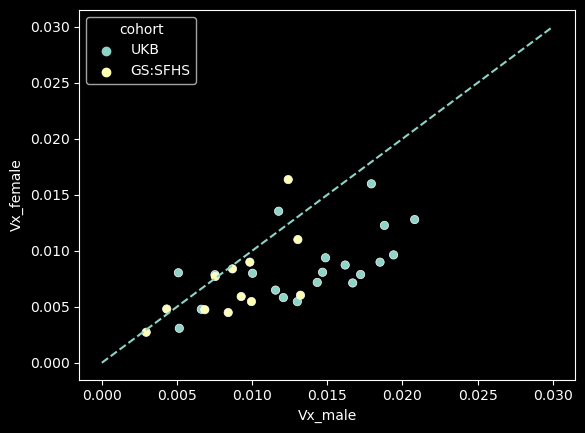

In [6]:
sns.scatterplot(
    data=df_mrg[df_mrg["weight"] == 1],
    x="Vx_male",
    y="Vx_female",
    hue="cohort"
)

plt.plot([0, 0.03], [0, 0.03], ls="--")

<Axes: xlabel='lambda', ylabel='Vx_male'>

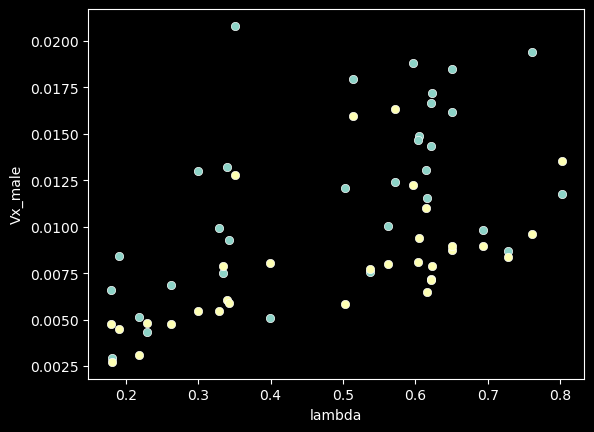

In [180]:
sns.scatterplot(
    data=df_mrg[df_mrg["weight"] == 1],
    x="lambda",
    y="Vx_male",
)

sns.scatterplot(
    data=df_mrg[df_mrg["weight"] == 1],
    x="lambda",
    y="Vx_female",
)


<Axes: xlabel='lambda', ylabel='Vx_female'>

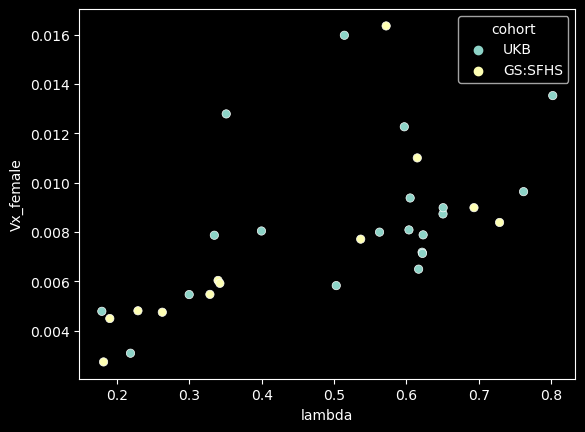

In [181]:
sns.scatterplot(
    data=df_mrg[df_mrg["weight"] == 1],
    x="lambda",
    y="Vx_female",
    hue="cohort"
)


In [182]:
df_mrg.to_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/figures/data/XmXfR.BIGFAM.tsv",
    sep='\t',
    index=False
)

## Step 2.2 UKB vs. GCTA

In [16]:
df_mrg = pd.merge(
    df_ukb_filtered,
    df_gcta_filtered,
    on="pheno",
    suffixes=["_BIGFAM", "_GCTA"]
)

In [184]:
# regression & correlation
df_reg = pd.DataFrame(
    columns=[
        "weight", "n_pheno",
        "slope_male", "se_slope_male",
        "corr_male", "se_corr_male",
        "slope_female", "se_slope_female",
        "corr_female", "se_corr_female"
    ]
)

for weight in sorted(df_mrg["weight"].unique()):
    tmp = df_mrg[df_mrg["weight"] == weight].copy()
    
    ll_male = smf.ols(
        formula="Vx_male_BIGFAM ~ 0 + Vx_male_GCTA",
        data=tmp
    ).fit()
    
    ll_female = smf.ols(
        formula="Vx_female_BIGFAM ~ 0 + Vx_female_GCTA",
        data=tmp
    ).fit()
    
    # corr
    corrs_male = []
    corrs_female = []
    for pheno in tmp["pheno"].unique():
        tmp_remove_one = tmp[tmp["pheno"] != pheno]
        corr_male = tmp_remove_one[["Vx_male_GCTA", "Vx_male_BIGFAM"]].corr().iloc[0, 1]
        corr_female = tmp_remove_one[["Vx_female_GCTA", "Vx_female_BIGFAM"]].corr().iloc[0, 1]
        
        corrs_male += [corr_male]
        corrs_female += [corr_female]
    
    df_reg.loc[len(df_reg)] = [
        weight, ll_male.nobs,
        ll_male.params["Vx_male_GCTA"], ll_male.bse["Vx_male_GCTA"], 
        np.mean(corrs_male), np.std(corrs_male),
        ll_female.params["Vx_female_GCTA"], ll_female.bse["Vx_female_GCTA"], 
        np.mean(corrs_female), np.std(corrs_female)
    ]
df_reg[[
    "weight", "n_pheno", 
    "slope_male", "slope_female",
    "corr_male", "corr_female", 
]].round(3)

,weight,n_pheno,slope_male,slope_female,corr_male,corr_female
0,-1.0,32.0,2.743,3.589,0.295,-0.085
1,0.0,24.0,1.737,1.835,0.495,0.101
2,1.0,16.0,1.091,1.112,0.950,0.648
3,2.0,18.0,0.693,0.636,0.680,0.635
4,3.0,13.0,0.381,0.368,0.616,0.585
5,4.0,16.0,0.257,0.225,0.356,0.389
6,5.0,14.0,0.187,0.161,0.121,0.133


In [185]:
df_mrg.groupby("weight").mean()[["DCR_BIGFAM", "DCR_GCTA"]]

,DCR_BIGFAM,DCR_GCTA
weight,,
-1,1.784087,1.798916
0,2.094032,1.878210
1,1.693945,1.846916
2,1.995176,1.867877
3,1.744962,1.815286
4,1.972354,1.839653
5,2.099655,1.904116


In [186]:
len(df_mrg["pheno"].unique())

34

In [18]:
for_plot = df_mrg[df_mrg["weight"] == 1]

In [20]:
for_plot.shape

(16, 20)

In [23]:
for_plot[["Vx_male_BIGFAM", "Vx_male_GCTA", "Vx_female_BIGFAM", "Vx_female_GCTA", "DCR_BIGFAM", "DCR_GCTA"]].agg(["mean", "std"]).T

,mean,std
Vx_male_BIGFAM,0.014027,0.004788
Vx_male_GCTA,0.012992,0.003654
Vx_female_BIGFAM,0.008314,0.002073
Vx_female_GCTA,0.007144,0.002315
DCR_BIGFAM,1.693945,0.460342
DCR_GCTA,1.846916,0.378038


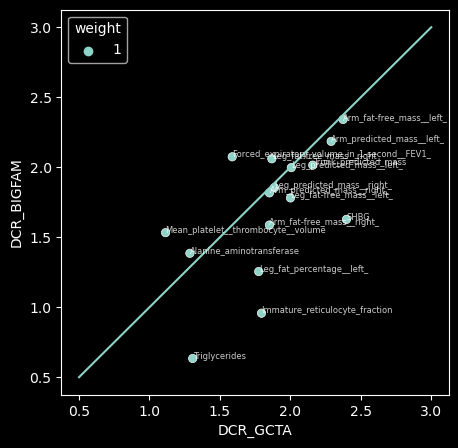

In [195]:
fig, ax = plt.subplots(figsize=(5, 5))

sns.scatterplot(
    data=for_plot,
    x="DCR_GCTA",
    y="DCR_BIGFAM",
    hue="weight",
    ax=ax
)


ax.plot([0.5, 3], [0.5, 3])

for i, pheno in enumerate(for_plot["pheno"]):
    x = for_plot.loc[for_plot["pheno"] == pheno, "DCR_GCTA"].values[0]
    y = for_plot.loc[for_plot["pheno"] == pheno, "DCR_BIGFAM"].values[0]
    # if i%2 == 0:
    #     continue
    ax.annotate(pheno, (x, y), fontsize=6, alpha=0.8)


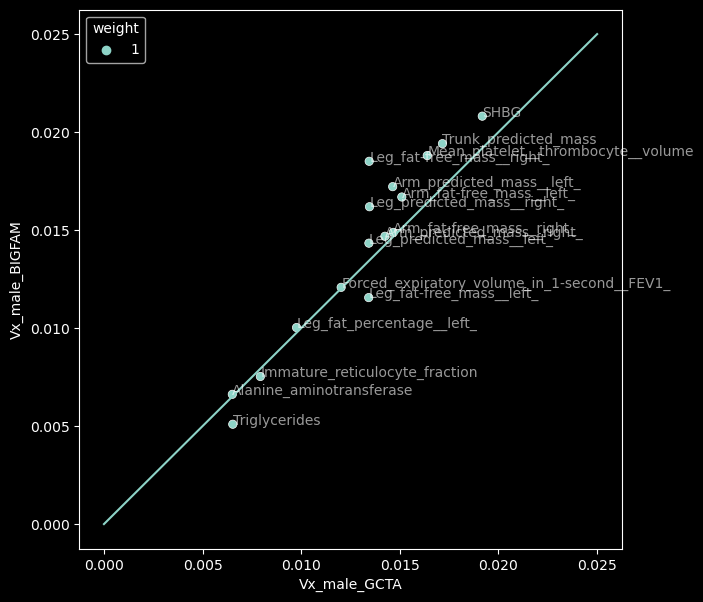

In [189]:
fig, ax = plt.subplots(figsize=(7, 7))

for_plot = df_mrg[df_mrg["weight"] == 1] #[(df_mrg["weight"] >= 1) & (df_mrg["weight"] < 4)],
sns.scatterplot(
    data=for_plot,
    x="Vx_male_GCTA",
    y="Vx_male_BIGFAM",
    hue="weight",
    ax=ax
)


ax.plot([0, 0.025], [0, 0.025])

for i, pheno in enumerate(for_plot["pheno"]):
    x = for_plot.loc[for_plot["pheno"] == pheno, "Vx_male_GCTA"].values[0]
    y = for_plot.loc[for_plot["pheno"] == pheno, "Vx_male_BIGFAM"].values[0]
    # if i%2 == 0:
    #     continue
    ax.annotate(pheno, (x, y), fontsize=10, alpha=0.6)


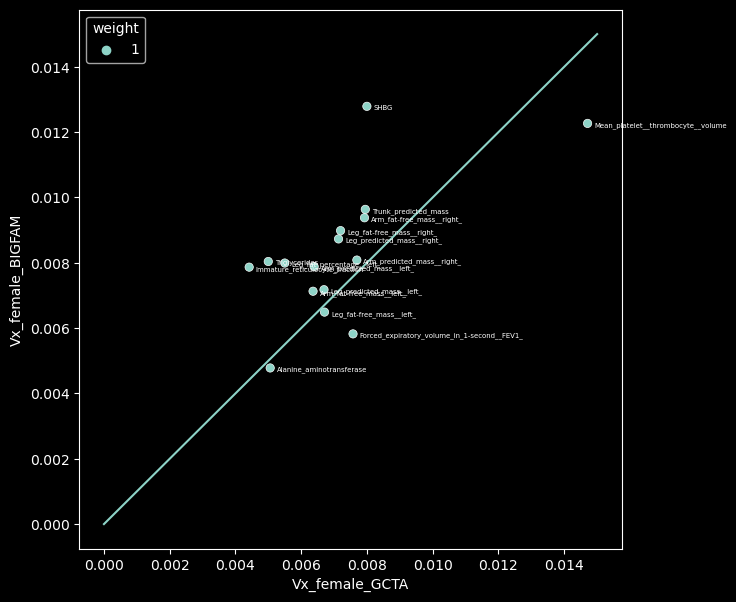

In [190]:
fig, ax = plt.subplots(figsize=(7, 7))

for_plot = df_mrg[df_mrg["weight"] == 1] #[(df_mrg["weight"] >= 1) & (df_mrg["weight"] < 4)],
sns.scatterplot(
    data=for_plot,
    x="Vx_female_GCTA",
    y="Vx_female_BIGFAM",
    hue="weight",
    ax=ax
)


ax.plot([0, 0.015], [0, 0.015])

for i, pheno in enumerate(for_plot["pheno"]):
    x = for_plot.loc[for_plot["pheno"] == pheno, "Vx_female_GCTA"].values[0]
    y = for_plot.loc[for_plot["pheno"] == pheno, "Vx_female_BIGFAM"].values[0]
    ax.annotate(pheno, (x+0.0002, y-0.0001), fontsize=5, alpha=1)


(-1.0, 2.0)

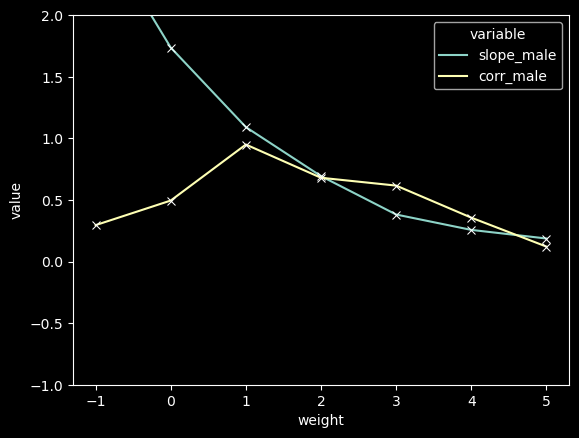

In [191]:
sns.lineplot(
    data=pd.melt(
        frame=df_reg,
        id_vars="weight",
        value_vars=["slope_male", "corr_male"]
    ),
    x="weight",
    y="value",
    hue="variable",
    marker="x"
)
plt.ylim([-1, 2])

(-1.0, 2.0)

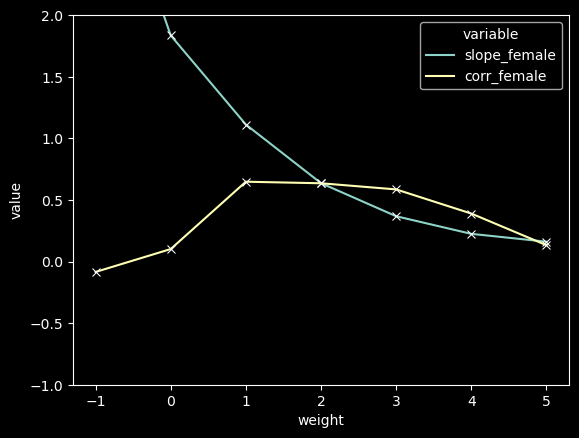

In [192]:
sns.lineplot(
    data=pd.melt(
        frame=df_reg,
        id_vars="weight",
        value_vars=["slope_female", "corr_female"]
    ),
    x="weight",
    y="value",
    hue="variable",
    marker="x"
)
plt.ylim([-1, 2])

In [193]:
df_mrg.to_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/figures/data/vs_snp.XmXfR.filitered.tsv",
    sep='\t',
    index=False
)